In [1]:
from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

import joblib
import pandas as pd
import seaborn as sns

from IPython.display import display

In [2]:
class DataLoader:
    
    def fetch_dataset(self):
        try:
            dataset = fetch_ucirepo(id=925)
            
            # return dataset
            X = dataset.data.features
            y = dataset.data.targets
            metadata = dataset.metadata

            # Combine X and y into a single DataFrame immediately
            # axis=1 aligns them side-by-side
            self.df = pd.concat([X, y], axis=1)
            
            return self.df, metadata
            
        except Exception as e:
            print(e)
            return None, None

    
    def wrangle_data(self):

        # Drop aveOralF target
        self.df = self.df.drop(columns=["aveOralF"])

        # Binary Map Gender and assign the previous dataframe to a new dataframe
        self.df_clean = self.df.assign(Gender=self.df['Gender'].map({'Male': 1, 'Female': 0}))

        # Age cleanup to keep data consistent
        self.df_clean["Age"] = self.df_clean["Age"].replace({
            "21-25": "21-30",
            "26-30": "21-30"
})

        self.df_clean.to_csv("dataset_preview.csv")
        
        return self.df_clean

In [3]:
class ModelTrainer:
    def __init__(self, X, y):
        self.X = X
        self.y = y

        self.X_train= None
        self.X_test= None
         
        self.y_train= None
        self.y_test= None

        # self.model = None
        self.results = []
         
    def split_data(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            train_size=0.8,
            random_state=42
        )
    
    def build_preprocessor(self, scale_numeric=False):
        categorical_features = ["Age", "Ethnicity"]
        numeric_features = [
            "T_atm", "Humidity", "Distance", "T_offset1", "Max1R13_1", "Max1L13_1", "aveAllR13_1", "aveAllL13_1",
            "T_RC1", "T_RC_Dry1", "T_RC_Wet1", "T_RC_Max1", "T_LC1", "T_LC_Dry1", "T_LC_Wet1", "T_LC_Max1",
            "RCC1", "LCC1", "canthiMax1", "canthi4Max1", "T_FHCC1", "T_FHRC1", "T_FHLC1", "T_FHBC1", "T_FHTC1",
            "T_FH_Max1", "T_FHC_Max1", "T_Max1", "T_OR1", "T_OR_Max1"
        ]
        
        if scale_numeric:
            numeric_transformer = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ])
        
        else:
            numeric_transformer = Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ])
            
        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ])
        
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_features),
                ("cat", categorical_transformer, categorical_features)
            ])
        
        return preprocessor
            
    def train_models(self):
        models = {
            "Linear Regression": LinearRegression(),
            "Ridge Regression": Ridge(alpha=1.0),
            "Random Forest": RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            ),
            "XGBoost": XGBRegressor(
                n_estimators=300,
                random_state=42
            )
        }
        
        best_r2 = -999
        best_pipeline = None
        best_model_name = None
        
        for name, model in models.items():
            print(f"Training {name}...:")

            scale_numeric = (name in ["Linear Regression", "Ridge Regression"])

            preprocessor = self.build_preprocessor(
                scale_numeric=scale_numeric
            )

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            pipeline.fit(self.X_train, self.y_train)

            predict = pipeline.predict(self.X_test)

            mae = mean_absolute_error(self.y_test, predict)

            rmse = root_mean_squared_error(self.y_test, predict)

            r2 = r2_score(self.y_test, predict)

            self.results.append({
                "Model": name,
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4),
                "R2": round(r2, 4)
            })

            if r2 > best_r2:
                best_r2 = r2
                best_pipeline = pipeline
                best_model_name = name

        results_df = pd.DataFrame(self.results).sort_values(by="R2", ascending=False)

        print("\nModel Comparison")
        # print(results_df)
        print(f"Best Model: {best_model_name}")
        print(f"Best r2: {best_r2:.4f}")

        joblib.dump(best_pipeline, "best_temperature_pipeline.pkl")

        return results_df


    def tune_random_forest(self):
        preprocessor = self.build_preprocessor(scale_numeric=False)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            ))
        ])
        param_dist = {
            "model__n_estimators": randint(100, 400),
            "model__max_depth": [None, 10, 20, 30],
            "model__min_samples_split": randint(2, 15),
            "model__min_samples_leaf": randint(1, 10)
        }

        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_dist,
            cv=3,
            n_iter=30,
            scoring="r2",
            n_jobs=-1,
            random_state=42,
            verbose=2
        )

        print("\nTuning Random Forest...")

        random_search.fit(self.X_train, self.y_train)

        best_model = random_search.best_estimator_

        predictions = best_model.predict(self.X_test)

        mae = mean_absolute_error(self.y_test, predictions)

        rmse = root_mean_squared_error(self.y_test, predictions)

        r2 = r2_score(self.y_test, predictions)

        print(f"""\nBest Parameters:
        {random_search.best_params_}
        """)

        print("\nTuned Random Forest Results:")
        print(f"""
        MAE: {mae:.4f}
        RMSE: {rmse:.4f}
        R²: {r2:.4f}
        """)

        return best_model
        

    def tune_ridge(self):
        preprocessor = self.build_preprocessor(scale_numeric=True)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", Ridge())
        ])

        param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]}

        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            verbose=1
        )

        print("\nTuning Ridge Regression...")

        grid.fit(self.X_train, self.y_train)

        best_model = grid.best_estimator_

        predictions = best_model.predict(self.X_test)

        mae = mean_absolute_error(self.y_test, predictions)

        rmse = root_mean_squared_error(self.y_test, predictions)

        r2 = r2_score(self.y_test, predictions)

        print(f"""\nBest Parameters:
        {grid.best_params_}
        """)

        print("\nTuned Ridge Results:")
        print(f"""
        MAE: {mae:.4f}
        RMSE: {rmse:.4f}
        R²: {r2:.4f}
        """)

        joblib.dump(best_model, "final_tuned_model.pkl")

        return best_model

In [4]:
def run():
    global df
    global cleaned_df
    
    loader = DataLoader()

    df, metadata = loader.fetch_dataset()
    cleaned_df = loader.wrangle_data()

    if df is None:
        print("Failed to load dataset")
        return

    print("Original merged dataset:")
    display(df.head())
    print(f"\n{df.info()}")
    

    # cleaned_df = loader.wrangle_data()
    print("Columns after wrangling:")
    display(cleaned_df.head())

    X = cleaned_df.drop(["aveOralM"], axis=1)
    y = cleaned_df["aveOralM"]

    print(X.shape)
    print(y.shape)

    # print(X.columns.tolist())
    # print(X.dtypes)

    trainer = ModelTrainer(X, y)

    trainer.split_data()

    results = trainer.train_models()

    print(results)

    result2 = trainer.tune_random_forest()

    print(result2)

    ridge_result = trainer.tune_ridge()
    
    return ridge_result

In [5]:
run()

Original merged dataset:


,Gender,Age,Ethnicity,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,...,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1,aveOralF,aveOralM
0,Male,41-50,White,24.0,28.0,0.8,0.7025,35.0300,35.3775,34.4000,...,33.3725,33.4925,33.0025,34.5300,34.0075,35.6925,35.6350,35.6525,36.85,36.59
1,Female,31-40,Black or African-American,24.0,26.0,0.8,0.7800,34.5500,34.5200,33.9300,...,33.6775,33.9700,34.0025,34.6825,34.6600,35.1750,35.0925,35.1075,37.00,37.19
2,Female,21-30,White,24.0,26.0,0.8,0.8625,35.6525,35.5175,34.2775,...,34.6475,34.8200,34.6700,35.3450,35.2225,35.9125,35.8600,35.8850,37.20,37.34
3,Female,21-30,Black or African-American,24.0,27.0,0.8,0.9300,35.2225,35.6125,34.3850,...,34.6550,34.3025,34.9175,35.6025,35.3150,35.7200,34.9650,34.9825,36.85,37.09
4,Male,18-20,White,24.0,27.0,0.8,0.8950,35.5450,35.6650,34.9100,...,34.3975,34.6700,33.8275,35.4175,35.3725,35.8950,35.5875,35.6175,36.80,37.04


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       1020 non-null   object 
 1   Age          1020 non-null   object 
 2   Ethnicity    1020 non-null   object 
 3   T_atm        1020 non-null   float64
 4   Humidity     1020 non-null   float64
 5   Distance     1018 non-null   float64
 6   T_offset1    1020 non-null   float64
 7   Max1R13_1    1020 non-null   float64
 8   Max1L13_1    1020 non-null   float64
 9   aveAllR13_1  1020 non-null   float64
 10  aveAllL13_1  1020 non-null   float64
 11  T_RC1        1020 non-null   float64
 12  T_RC_Dry1    1020 non-null   float64
 13  T_RC_Wet1    1020 non-null   float64
 14  T_RC_Max1    1020 non-null   float64
 15  T_LC1        1020 non-null   float64
 16  T_LC_Dry1    1020 non-null   float64
 17  T_LC_Wet1    1020 non-null   float64
 18  T_LC_Max1    1020 non-null   float64
 19  RCC1  

,Gender,Age,Ethnicity,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,...,T_FHRC1,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1,aveOralM
0,1,41-50,White,24.0,28.0,0.8,0.7025,35.0300,35.3775,34.4000,...,33.4775,33.3725,33.4925,33.0025,34.5300,34.0075,35.6925,35.6350,35.6525,36.59
1,0,31-40,Black or African-American,24.0,26.0,0.8,0.7800,34.5500,34.5200,33.9300,...,34.0550,33.6775,33.9700,34.0025,34.6825,34.6600,35.1750,35.0925,35.1075,37.19
2,0,21-30,White,24.0,26.0,0.8,0.8625,35.6525,35.5175,34.2775,...,34.8275,34.6475,34.8200,34.6700,35.3450,35.2225,35.9125,35.8600,35.8850,37.34
3,0,21-30,Black or African-American,24.0,27.0,0.8,0.9300,35.2225,35.6125,34.3850,...,34.4225,34.6550,34.3025,34.9175,35.6025,35.3150,35.7200,34.9650,34.9825,37.09
4,1,18-20,White,24.0,27.0,0.8,0.8950,35.5450,35.6650,34.9100,...,35.1600,34.3975,34.6700,33.8275,35.4175,35.3725,35.8950,35.5875,35.6175,37.04


(1020, 33)
(1020,)
Training Linear Regression...:
Training Ridge Regression...:
Training Random Forest...:
Training XGBoost...:

Model Comparison
Best Model: Ridge Regression
Best r2: 0.7499
               Model     MAE    RMSE      R2
1   Ridge Regression  0.1863  0.2295  0.7499
0  Linear Regression  0.1872  0.2311  0.7463
2      Random Forest  0.1853  0.2403  0.7257
3            XGBoost  0.1936  0.2554  0.6903

Tuning Random Forest...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best Parameters:
        {'model__max_depth': 20, 'model__min_samples_leaf': 6, 'model__min_samples_split': 6, 'model__n_estimators': 357}
        

Tuned Random Forest Results:

        MAE: 0.1820
        RMSE: 0.2367
        R²: 0.7340
        
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['T_atm', 'Humidity',
                                                   'Distance', 'T_offset1',
                                                   'Max1R13_1', 'Max1L13_1',
                                                   'aveAllR13_1', 'aveAllL13_1',
                                                   'T_RC1', 'T_RC_Dry1',
                                                   'T_RC_Wet1', 'T_RC_Max1',
                                                   'T_LC1', 'T_LC_Dry1',
                                                   'T_LC_Wet1', 'T_LC_Max1',
                                                   'RCC1', 'LCC1', 'canthiMax1',
                                                   'canthi4Max1', 'T_FHCC1',
                                                   'T_FHRC1', 'T_FHLC1',
                                                   'T_FHBC1', 'T_FHTC1',
                                                   'T_FH_Max1', 'T_FHC_Max1',
                                                   'T_Max1', 'T_OR1',
                                                   'T_OR_Max1']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Age', 'Ethnicity'])])),
                ('model', Ridge(alpha=200))])

In [6]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       1020 non-null   int64  
 1   Age          1020 non-null   object 
 2   Ethnicity    1020 non-null   object 
 3   T_atm        1020 non-null   float64
 4   Humidity     1020 non-null   float64
 5   Distance     1018 non-null   float64
 6   T_offset1    1020 non-null   float64
 7   Max1R13_1    1020 non-null   float64
 8   Max1L13_1    1020 non-null   float64
 9   aveAllR13_1  1020 non-null   float64
 10  aveAllL13_1  1020 non-null   float64
 11  T_RC1        1020 non-null   float64
 12  T_RC_Dry1    1020 non-null   float64
 13  T_RC_Wet1    1020 non-null   float64
 14  T_RC_Max1    1020 non-null   float64
 15  T_LC1        1020 non-null   float64
 16  T_LC_Dry1    1020 non-null   float64
 17  T_LC_Wet1    1020 non-null   float64
 18  T_LC_Max1    1020 non-null   float64
 19  RCC1  

In [99]:
correlation = df.select_dtypes("number").drop(columns="aveOralM").corr()

correlation

,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,aveAllL13_1,T_RC1,T_RC_Dry1,T_RC_Wet1,T_RC_Max1,T_LC1,T_LC_Dry1,T_LC_Wet1,T_LC_Max1,RCC1,LCC1,canthiMax1,canthi4Max1,T_FHCC1,T_FHRC1,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1
T_atm,1.000000,0.119270,0.033377,0.616912,0.275363,0.292344,0.269869,0.311260,0.287289,0.280530,0.317640,0.285080,0.301102,0.295209,0.349119,0.298418,0.326152,0.347894,0.287574,0.289473,0.380148,0.368740,0.388760,0.393838,0.329755,0.339329,0.389521,0.242280,0.233001,0.230146
Humidity,0.119270,1.000000,0.008468,0.224086,0.050884,0.060754,0.101012,0.112754,0.058080,0.044929,0.082547,0.057643,0.064622,0.057882,0.088858,0.064127,0.102132,0.119523,0.051423,0.052275,0.043393,0.033311,0.040234,0.061012,0.036980,0.006943,0.038868,0.064231,0.111888,0.110408
Distance,0.033377,0.008468,1.000000,0.024831,-0.024479,-0.022900,-0.051634,-0.054362,-0.012427,-0.024331,-0.007114,-0.012356,-0.023953,-0.021779,-0.024545,-0.023781,-0.028424,-0.029002,-0.018007,-0.018102,-0.018626,-0.008938,-0.009554,-0.022870,-0.014081,-0.022385,-0.012941,0.007898,0.013631,0.014242
T_offset1,0.616912,0.224086,0.024831,1.000000,0.239208,0.260545,0.237177,0.279728,0.249420,0.242019,0.280940,0.247770,0.273519,0.265144,0.318205,0.271318,0.291964,0.320351,0.246427,0.248348,0.367158,0.348724,0.368220,0.371284,0.317587,0.304540,0.355541,0.191369,0.181496,0.177910
Max1R13_1,0.275363,0.050884,-0.024479,0.239208,1.000000,0.901213,0.868731,0.825698,0.981819,0.995478,0.942309,0.981113,0.902975,0.906336,0.867610,0.901981,0.950207,0.848891,0.955850,0.956726,0.673311,0.665614,0.617565,0.702868,0.566860,0.703221,0.720179,0.873412,0.734474,0.733324
Max1L13_1,0.292344,0.060754,-0.022900,0.260545,0.901213,1.000000,0.775313,0.896370,0.906892,0.901218,0.895895,0.905858,0.988479,0.993080,0.945383,0.988293,0.878140,0.938003,0.951890,0.952341,0.660783,0.640706,0.612534,0.692723,0.559005,0.691522,0.707298,0.867470,0.729175,0.727941
aveAllR13_1,0.269869,0.101012,-0.051634,0.237177,0.868731,0.775313,1.000000,0.858994,0.826354,0.868849,0.768282,0.825342,0.769817,0.774904,0.728465,0.768811,0.851173,0.759324,0.811333,0.812102,0.636518,0.609243,0.581719,0.683231,0.535339,0.628209,0.664829,0.745489,0.657640,0.656137
aveAllL13_1,0.311260,0.112754,-0.054362,0.279728,0.825698,0.896370,0.858994,1.000000,0.809478,0.826757,0.788077,0.808872,0.878311,0.889209,0.826994,0.876763,0.824750,0.874104,0.849653,0.850296,0.650243,0.620341,0.599982,0.697290,0.551961,0.653166,0.677782,0.774758,0.675740,0.674287
T_RC1,0.287289,0.058080,-0.012427,0.249420,0.981819,0.906892,0.826354,0.809478,1.000000,0.982699,0.974507,0.999788,0.917951,0.914081,0.893988,0.917171,0.941622,0.862210,0.973427,0.974158,0.675262,0.667143,0.620701,0.704861,0.570513,0.715962,0.729618,0.892319,0.746736,0.745588
T_RC_Dry1,0.280530,0.044929,-0.024331,0.242019,0.995478,0.901218,0.868849,0.826757,0.982699,1.000000,0.939192,0.981766,0.904788,0.908854,0.869295,0.903646,0.938857,0.846625,0.958114,0.959138,0.686645,0.678681,0.630409,0.717506,0.579582,0.718977,0.734562,0.878937,0.736340,0.735246


## Multicollinearity Heatmap

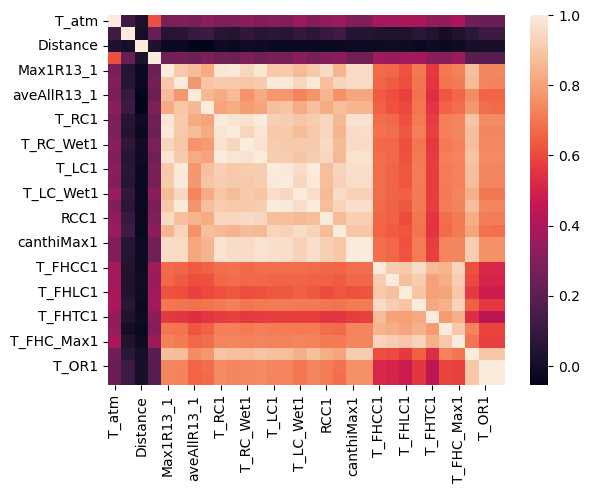

In [100]:
sns.heatmap(correlation);

In [105]:
# Identify null values
df.isna().sum()

Gender         0
Age            0
Ethnicity      0
T_atm          0
Humidity       0
Distance       2
T_offset1      0
Max1R13_1      0
Max1L13_1      0
aveAllR13_1    0
aveAllL13_1    0
T_RC1          0
T_RC_Dry1      0
T_RC_Wet1      0
T_RC_Max1      0
T_LC1          0
T_LC_Dry1      0
T_LC_Wet1      0
T_LC_Max1      0
RCC1           0
LCC1           0
canthiMax1     0
canthi4Max1    0
T_FHCC1        0
T_FHRC1        0
T_FHLC1        0
T_FHBC1        0
T_FHTC1        0
T_FH_Max1      0
T_FHC_Max1     0
T_Max1         0
T_OR1          0
T_OR_Max1      0
aveOralM       0
dtype: int64

In [146]:
print(df["Ethnicity"].value_counts(normalize=True))
print("")
print(df["Age"].value_counts())

Ethnicity
White                                0.496078
Asian                                0.254902
Black or African-American            0.140196
Hispanic/Latino                      0.055882
Multiracial                          0.049020
American Indian or Alaskan Native    0.003922
Name: proportion, dtype: float64

Age
18-20    534
21-25    355
26-30     67
31-40     31
51-60     11
21-30     10
41-50      9
>60        3
Name: count, dtype: int64


<Axes: title={'center': 'Class Balance'}, xlabel='Age', ylabel='Relative Frequency'>

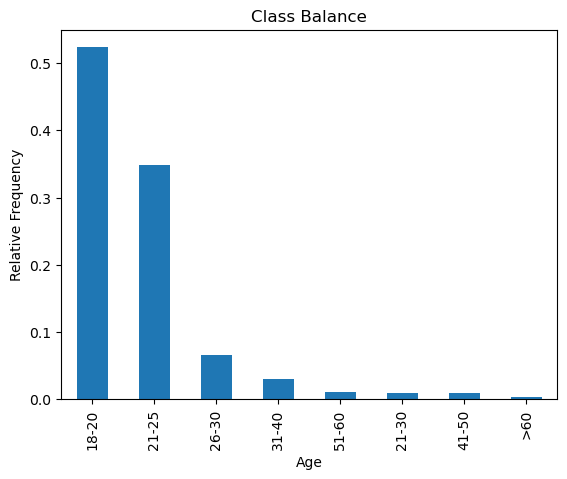

In [114]:
df["Age"].value_counts(normalize=True).plot(kind="bar", xlabel="Age", ylabel="Relative Frequency", title="Class Balance")

<Axes: title={'center': 'Class Balance'}, xlabel='Ethnicity', ylabel='Relative Frequency'>

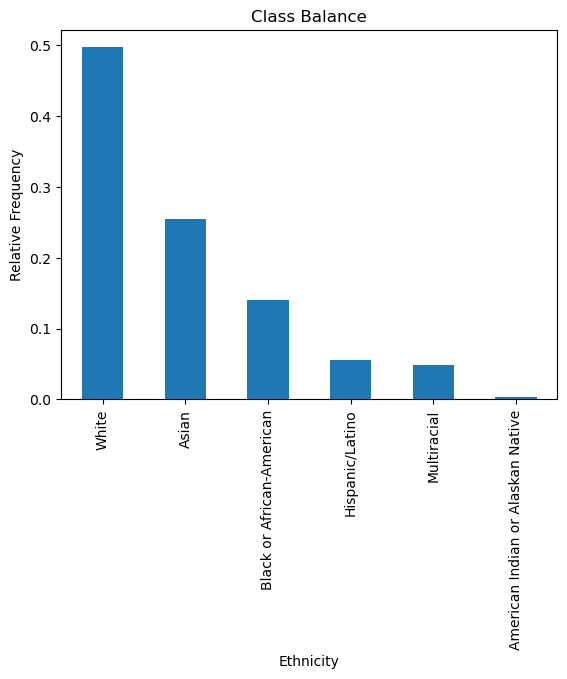

In [115]:
df["Ethnicity"].value_counts(normalize=True).plot(kind="bar", xlabel="Ethnicity", ylabel="Relative Frequency", title="Class Balance")

<Axes: xlabel='Age', ylabel='aveOralM'>

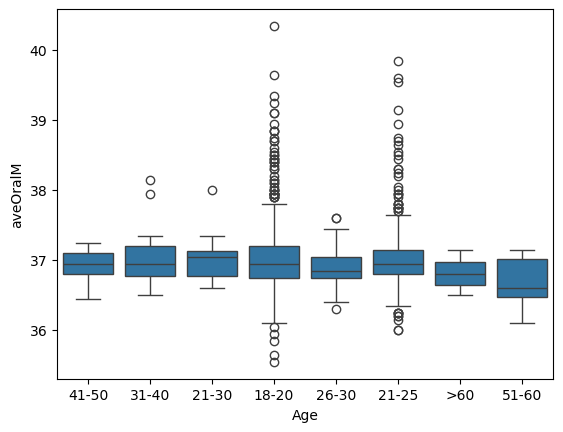

In [116]:
sns.boxplot(
    x="Age",
    y="aveOralM",
    data=df
)

<Axes: xlabel='Ethnicity', ylabel='aveOralM'>

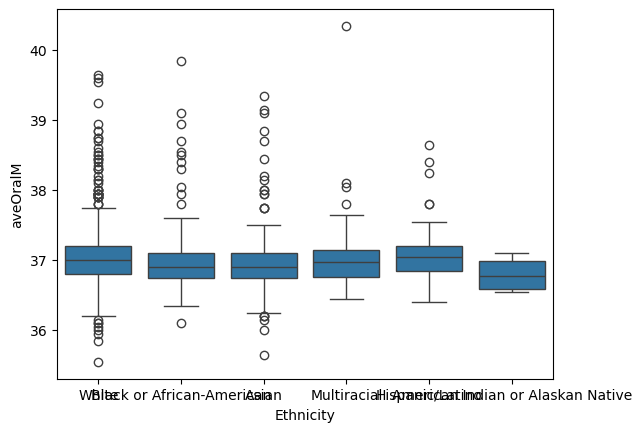

In [123]:
sns.boxplot(
    x="Ethnicity",
    y="aveOralM",
    data=df,
)

In [150]:
cleaned_df["Age"].value_counts()

Age
18-20    534
21-30    432
31-40     31
51-60     11
41-50      9
>60        3
Name: count, dtype: int64